In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

In [2]:
# ============================================================
# LOAD DATA 
# ============================================================

import pandas as pd

X = pd.read_csv("C:/Users/Acer/Desktop/House Pricing R/data/Cleaned/X_encoded.csv")
y = pd.read_csv("C:/Users/Acer/Desktop/House Pricing R/data/Cleaned/y.csv").values.ravel()

In [3]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [4]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    oob_score=True

)

rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,True


In [5]:
y_pred_rf = rf_model.predict(X_val)

In [6]:
rmse_rf = np.sqrt(mean_squared_error(y_val, y_pred_rf))
print("Random Forest RMSE:", rmse_rf)

Random Forest RMSE: 0.14490267385977745


In [7]:
print("OOB Score :", rf_model.oob_score_)

OOB Score : 0.88328925044062


In [8]:
from sklearn.metrics import r2_score

In [9]:
r2_rf = r2_score(y_val, y_pred_rf)

print("R² Score :", r2_rf)

R² Score : 0.8670590194585912


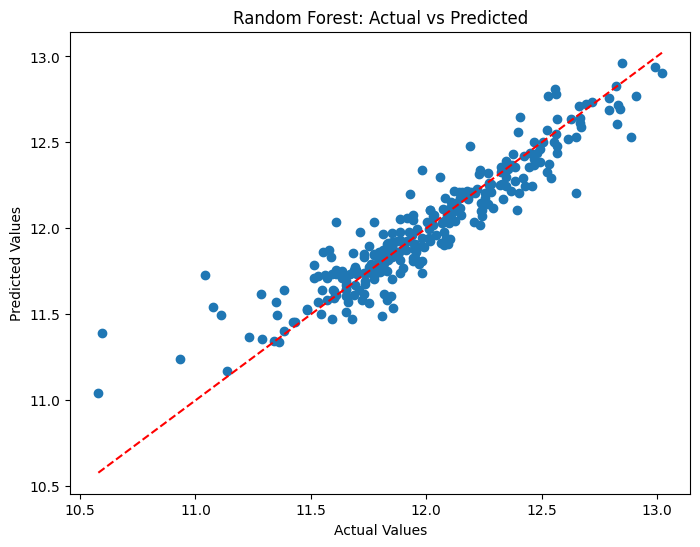

In [10]:
plt.figure(figsize=(8,6))

plt.scatter(y_val, y_pred_rf)

plt.plot(
    [y_val.min(), y_val.max()],
    [y_val.min(), y_val.max()],
    'r--'
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Random Forest: Actual vs Predicted")

plt.show()

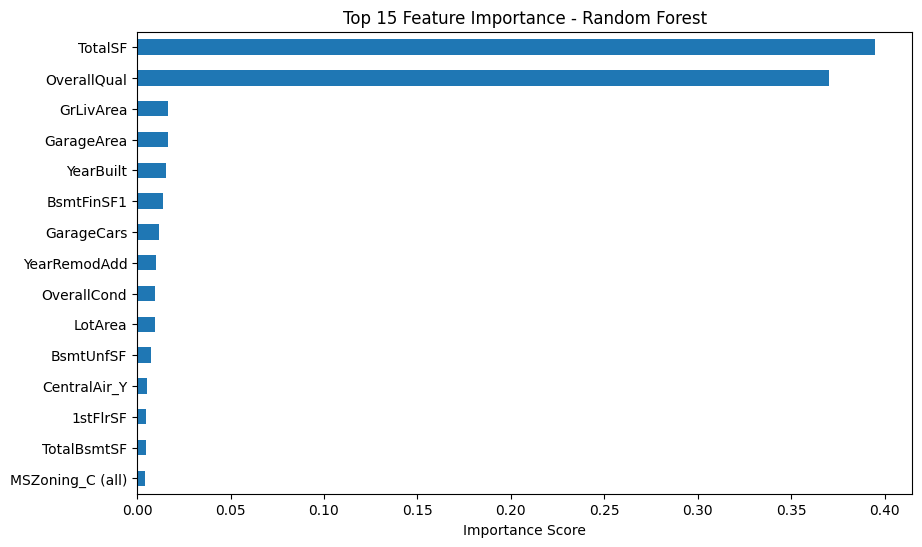

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
)

# Top 15 variables les plus importantes
top_features = feature_importance.sort_values(ascending=False).head(15)

plt.figure(figsize=(10,6))

top_features.sort_values().plot(kind='barh')

plt.title("Top 15 Feature Importance - Random Forest")

plt.xlabel("Importance Score")

plt.show()

In [12]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_features='sqrt',
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    oob_score=True,
    random_state=42,
    n_jobs=-1
)

C:\Users\Acer\projet1\Lib\site-packages\sklearn\ensemble\_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
C:\Users\Acer\projet1\Lib\site-packages\sklearn\ensemble\_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


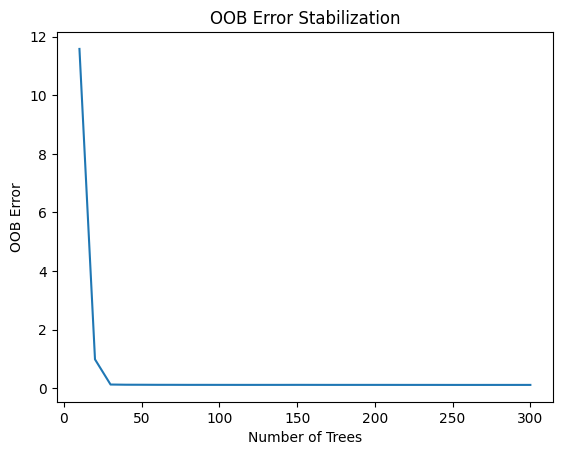

In [13]:
errors = []

for n in range(10, 301, 10):

    rf_temp = RandomForestRegressor(
        n_estimators=n,
        oob_score=True,
        random_state=42,
        n_jobs=-1
    )

    rf_temp.fit(X_train, y_train)

    errors.append(1 - rf_temp.oob_score_)

plt.plot(range(10, 301, 10), errors)

plt.xlabel("Number of Trees")
plt.ylabel("OOB Error")
plt.title("OOB Error Stabilization")

plt.show()